In [1]:

# --- Probability with Sets Example ---

# Total sample space: 100 countries
sample_space = set(range(1, 101))

# Countries using >50% renewable energy
renewable = set(range(1, 61))  # 60 countries

# Countries using <10% fossil fuels
low_fossil = set(range(41, 81))  # 40 countries

# Intersection: countries that meet both criteria
both = renewable & low_fossil

# Basic probabilities
P_A = len(renewable) / len(sample_space)
P_B = len(low_fossil) / len(sample_space)
P_A_and_B = len(both) / len(sample_space)

# Conditional probability: P(A | B)
P_A_given_B = P_A_and_B / P_B

# Print results
print("P(Renewable > 50%):", round(P_A, 2))
print("P(Fossil < 10%):", round(P_B, 2))
print("P(Both):", round(P_A_and_B, 2))
print("P(Renewable | Low Fossil):", round(P_A_given_B, 2))


P(Renewable > 50%): 0.6
P(Fossil < 10%): 0.4
P(Both): 0.2
P(Renewable | Low Fossil): 0.5


In [3]:

# --- Bayes' Theorem Example in Python ---

# P(A): probability of power blackout
P_blackout = 0.10

# P(B | A): probability of heatwave on blackout days
P_heatwave_given_blackout = 0.80

# P(B): overall probability of heatwave
P_heatwave = 0.30

# Bayes' Theorem: P(A | B) = [P(B | A) * P(A)] / P(B)
P_blackout_given_heatwave = (P_heatwave_given_blackout * P_blackout) / P_heatwave

# Display result
print("Probability of blackout given heatwave:", round(P_blackout_given_heatwave, 3))


Probability of blackout given heatwave: 0.267


In [12]:

# Step 1: Load the messy dataset
import pandas as pd

df = pd.read_csv("energy_raw.csv")
print("Original Data:")
print(df)

# Step 2: Count missing values
print("\nMissing values:")
print(df.isnull().sum())

# Step 3: Standardize country names and numeric fields
df["Country"] = df["Country"].str.strip().str.title()
df["%Renewable"] = pd.to_numeric(df["%Renewable"].str.replace("%", ""), errors="coerce")

# Step 4: Remove duplicates and unrealistic values
df = df.drop_duplicates()
df = df[df["%Renewable"] <= 100]

# Step 5: View cleaned data
print("\nCleaned Data:")
print(df)



Original Data:
     Country %Renewable         Region
0      Nepal         89           Asia
1     india          45           Asia
2      KENYA        NaN         Africa
3     Brazil        105  South America
4     Brazil        105  South America
5  Australia        NaN        Oceania
6    Germany         48         Europe
7      kenya        50%         africa

Missing values:
Country       0
%Renewable    2
Region        0
dtype: int64

Cleaned Data:
   Country  %Renewable  Region
0    Nepal        89.0    Asia
1    India        45.0    Asia
6  Germany        48.0  Europe
7    Kenya        50.0  africa


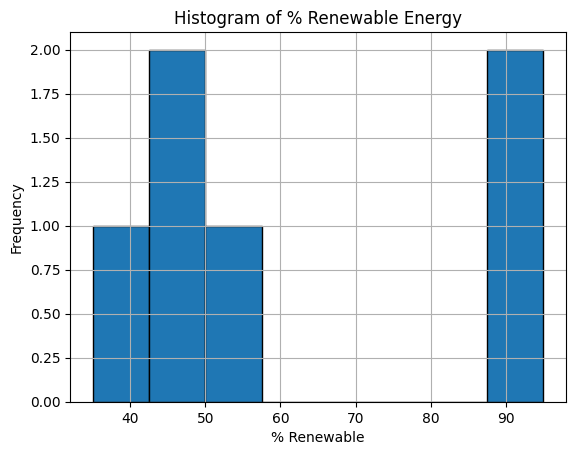

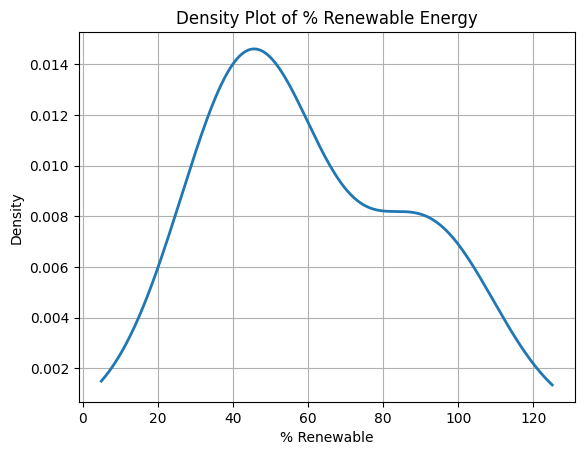

Skipped Africa: only 1 valid value
Skipped Europe: only 1 valid value
Skipped Oceania: only 1 valid value
Skipped South America: only 1 valid value


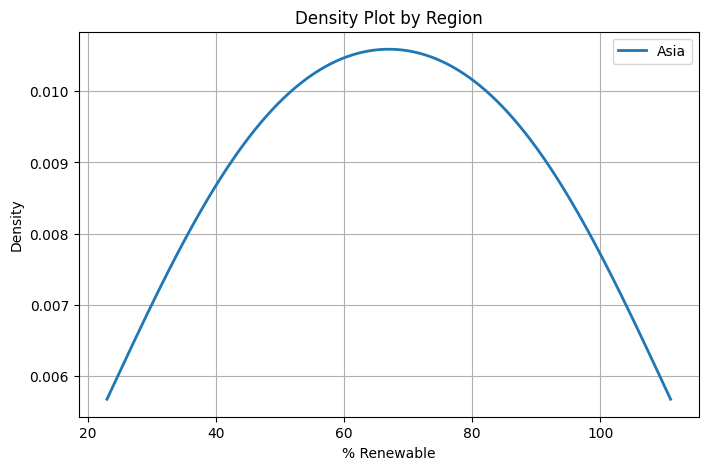

In [15]:

# Exploratory Data Analysis: Histograms and KDE

import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned data
df = pd.read_csv("energy_cleaned.csv")

# Histogram
df["%Renewable"].plot(kind="hist", bins=8, edgecolor="black")
plt.title("Histogram of % Renewable Energy")
plt.xlabel("% Renewable")
plt.grid(True)
plt.show()

# KDE plot (requires scipy)
df["%Renewable"].plot(kind="density", linewidth=2)
plt.title("Density Plot of % Renewable Energy")
plt.xlabel("% Renewable")
plt.grid(True)
plt.show()

# KDE by Region
if "Region" in df.columns:
    plt.figure(figsize=(8, 5))

    for region, group in df.groupby("Region"):
        values = pd.to_numeric(group["%Renewable"], errors="coerce").dropna()

        if len(values) > 1:
            values.plot(kind="density", linewidth=2, label=region)
        else:
            print(f"Skipped {region}: only {len(values)} valid value")

    plt.title("Density Plot by Region")
    plt.xlabel("% Renewable")
    plt.legend()
    plt.grid(True)
    plt.show()